Projeto final - Módulo 1 - SCTEC

# Fase 1: Análise Exploratória (EDA)

Apresente as dimensões do dataset (número de linhas e colunas), os tipos de dados das variáveis e o resumo estatístico descritivo das colunas numéricas via método “.describe()”.

Plote, no mínimo, 3 gráficos analíticos bem fundamentados utilizando bibliotecas como Matplotlib ou Seaborn (Ex: histograma de distribuição das variáveis preditoras, gráfico de barras comprovando a taxa de desbalanceamento da variável alvo e um mapa de calor com a correlação de Pearson entre as variáveis).

Insira uma célula de texto analisando os valores numéricos e os padrões identificados nos gráficos, explicitando como eles direcionam a estratégia de modelagem.


## Antes de começar, selecionar o Kernel ".venv" e configurar o notebook

In [ ]:
# Configuração inicial de todos os notebooks (ver o src.config)

# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuração do visual global
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

print("n\=== CONFIGURAÇÕES E BIBLIOTECAS IMPORTADAS COM SUCESSO ===")

# Carregando os dados do dataset

In [ ]:
# Leitura do arquivo

df = pd.read_csv("../data/raw/manutencao_preditiva.csv", sep=",")
df.head()


In [ ]:
# Apresentar as dimenções do dataset

df.describe()

In [ ]:
# Inspecionar o dataset 

df.info()

# Análise gráfica dos dados ainda sem tratamento

O objetivo deste projeto é prever quebras mecânicas nos equipamentos para evitar paradas na linha de produção.
Logo, os gráficos de diagnóstico inicial devem focar no comportamento de opereração normal versus o comportamento que antecede a quebra.
O mapa de calor é o gráfico que mostra imediatamente a correlação entre as falhas e as variáveis, além de ignorar valores ausentes e direcionar a limpeza dos outliers.

In [ ]:
# Para os gráficos serem salvos na pasta "outputs"

def salvar_grafico(nome_arquivo, etapa="01_eda", output_base_dir="../outputs/graficos"): # cria a subpasta para a etapa atual e exporta o gráfico gerado
    output_dir = os.path.join(output_base_dir, etapa)
    os.makedirs(output_dir, exist_ok=True) # cria o caminho dinâmico

    caminho_completo = os.path.join(output_dir, f"{nome_arquivo}.png") # define o caminho final do arquivo de imagem

    plt.savefig(caminho_completo, dpi=300, bbox_inches="tight")
    print(f"Grafico salvo em:{caminho_completo}") #salva o grafico atual

Grafico salvo em:../outputs/graficos\01_eda\01_mapa_de_calor.png


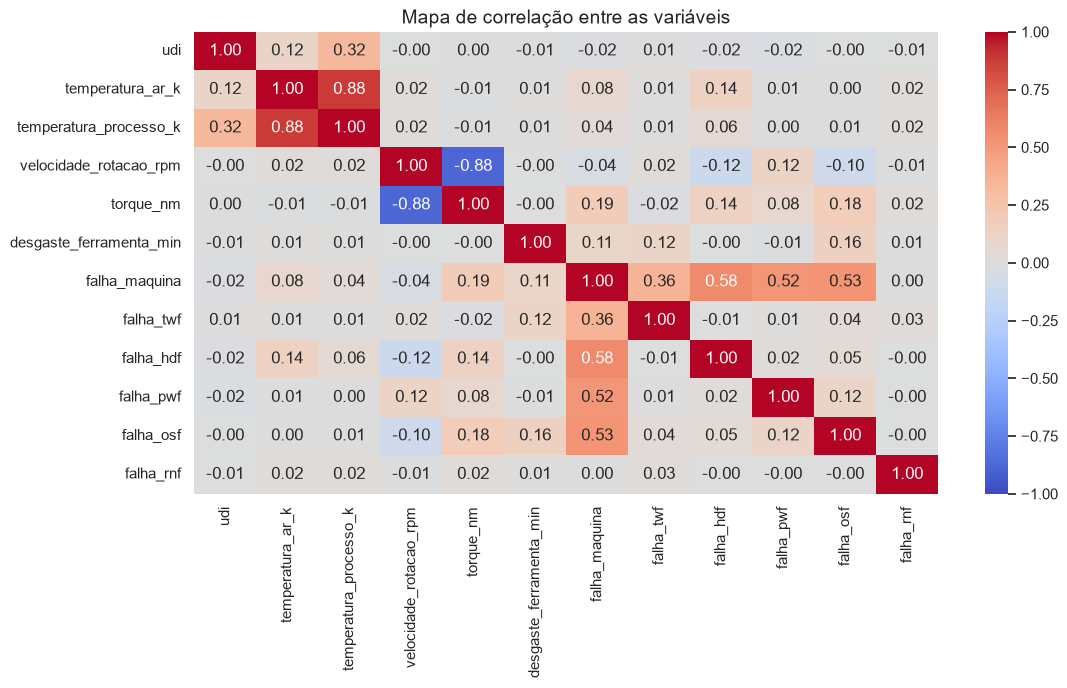

In [65]:
# Mapa de calor: diagnóstico de correlação das variáveis

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Mapa de correlação entre as variáveis")
salvar_grafico("01_mapa_de_calor")
plt.show()

Análise:

Pelo mapa de calor é possível observar uma correlação muito forte, quase linear, entre as temperaturas do ar e de processo (0.88) e entre a velocidade de rotação e o torque (-0.88). O sinal negativo na correlação entre a velocidade de rotação e o torque indica que a correlação é inversa, ou seja, quando aumenta a velocidade de rotação, reduz-se o torque, um comportamento esperado na mecânica. Já para a temperatura, a correlação é positiva, indicando que quando o ar está mais aquecido, o processo também apresenta temperaturas mais elevadas.
Desconsiderando as variáveis que indicam o tipo de falha, é possível observar que o torque e o desgaste da ferramenta são as variáveis com maior correlação com a variável de falha. Apesar disso, os valores são muito baixos, indicando que não existe uma correlação linear direta e simples. A causa das quebras deve ser multifatorial. O histograma vai ajudar a entender o comportamento físico das máquinas através da distribuição dos dados com falha e em condições sem falha.

Grafico salvo em:../outputs/graficos\01_eda\02_histogramas.png


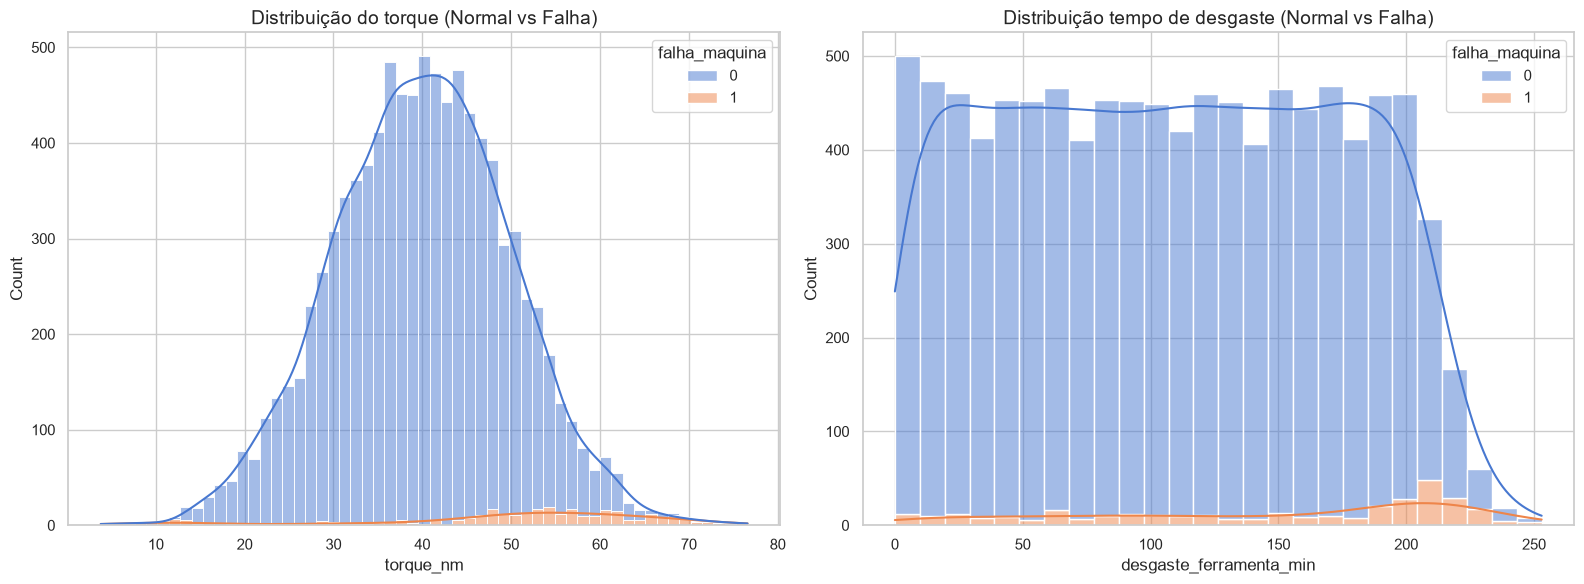

In [64]:
# Histogramas das variáveis com maiores correlações com as falhas

fig, axes = plt.subplots(1, 2, figsize=(16,6)) # para os gráficos sairem lado a lado

# Histograma do torque
sns.histplot(data=df, x='torque_nm', hue='falha_maquina', kde=True, ax=axes[0], multiple="stack") # o hue faz o histograma mostrar em cores diferentes quando há (1) e quando não há falha (0)
axes [0].set_title('Distribuição do torque (Normal vs Falha)')

# Histograma do desgaste da ferramenta
sns.histplot(data=df, x='desgaste_ferramenta_min', hue='falha_maquina', kde=True, ax=axes[1], multiple="stack") 
axes [1].set_title('Distribuição tempo de desgaste (Normal vs Falha)')

plt.tight_layout()
salvar_grafico("02_histogramas")
plt.show()


Análise:

Pelo histograma do torque é possível observar que as falhas começam a partir de 42Nm. Abaixo disso, as máquina operam em segurança e acima, os equipamentos estão mais vulneráveis a quebra por sobrecarga.
Já o histograma do desgaste da ferramenta mostra que existem falhas desde o minuto zero, mas com um pico entre 190 e 240 minutos, que indica o fim da vida útil da ferramenta por desgaste natural (fadiga).
Para comparar a média do tempo de desgaste da ferramenta para as condições de operação normal e com falha, foi gerado um gráfico de barras:

Grafico salvo em:../outputs/graficos\01_eda\03_barras.png


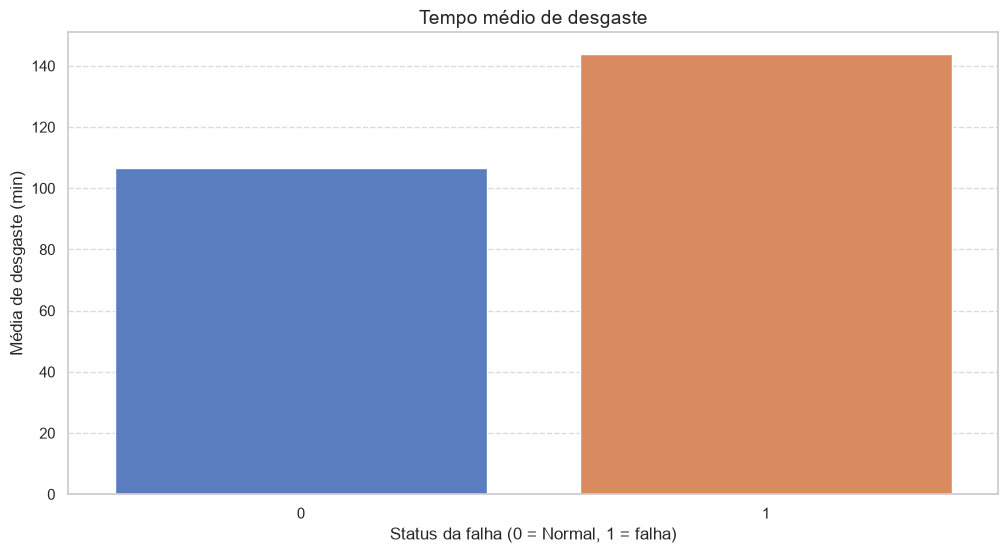

In [66]:
# Gráfico de barras para o tempo médio de operação normal e de falha

sns.barplot(data=df, x='falha_maquina', y='desgaste_ferramenta_min', palette='muted', hue='falha_maquina', legend=False, errorbar=None)

plt.title("Tempo médio de desgaste")
plt.xlabel('Status da falha (0 = Normal, 1 = falha)')
plt.ylabel('Média de desgaste (min)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
salvar_grafico("03_barras")
plt.show()

Análise: 

A média de aproximadamente 100 minutos para a operação normal e de 140 minutos para a operação com falha mostra que o desgaste acumulado aumetna a chance de falha. No entanto, se as quebras acontececem somente por desgaste avançado, a média da barra com falha deveria ser mais alta, perto de 200 minutos, que é o pico mostrado no histograma. A média do tempo de falha por desgaste está sendo afetada pelas quebras prematuras, que aparecem desde o tempo zero no histograma.